In [2]:
# Mount Google Drive.
from google.colab import drive
drive.mount('/content/drive')

# Import the libraries we need.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the project folder.
project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

# Define the dataset paths.
data_path = project_path + '/data/raw/archive/data/data'
train_path = data_path + '/train'
test_path = data_path + '/test'

# Define the anomaly label file.
labels_path = project_path + '/data/raw/archive/labeled_anomalies.csv'

print("SERIAL 14 loaded successfully.")
print("Project folder exists:", os.path.exists(project_path))
print("Test folder exists:", os.path.exists(test_path))
print("Labels file exists:", os.path.exists(labels_path))

Mounted at /content/drive
SERIAL 14 loaded successfully.
Project folder exists: True
Test folder exists: True
Labels file exists: True


###Load A-8 telemetry

In [3]:
# Select the channel we will use to understand the rolling method.
channel = "A-8"

# Load the A-8 test data.
data_A8 = np.load(test_path + "/" + channel + ".npy")

# The first column contains the main telemetry signal.
telemetry_A8 = data_A8[:, 0]

# Load the ground-truth anomaly labels.
labels_df = pd.read_csv(labels_path)

# Get the anomaly information for A-8.
A8_info = labels_df[labels_df["chan_id"] == channel].iloc[0]

print("Channel:", channel)
print("Test data shape:", data_A8.shape)
print("Telemetry points:", len(telemetry_A8))
print("Ground-truth anomaly:", A8_info["anomaly_sequences"])
print("Anomaly class:", A8_info["class"])

Channel: A-8
Test data shape: (8375, 25)
Telemetry points: 8375
Ground-truth anomaly: [[4569, 8374]]
Anomaly class: [contextual]


###Calculate Rolling Mean and Standard Deviation

In [4]:
# Define the rolling window size.
window = 50

# Convert the telemetry into a Pandas Series.
telemetry_series = pd.Series(telemetry_A8)

# Calculate the rolling mean using the previous 50 points.
rolling_mean = telemetry_series.rolling(window=window).mean()

# Calculate the rolling standard deviation using the previous 50 points.
rolling_std = telemetry_series.rolling(window=window).std()

print("Rolling window:", window)
print("Rolling mean calculated:", rolling_mean.notna().sum())
print("Rolling standard deviation calculated:", rolling_std.notna().sum())

Rolling window: 50
Rolling mean calculated: 8326
Rolling standard deviation calculated: 8326


In [5]:
# Use only previous 50 points for the rolling statistics.
window = 50

telemetry_series = pd.Series(telemetry_A8)

rolling_mean = (
    telemetry_series
    .shift(1)
    .rolling(window=window, min_periods=window)
    .mean()
)

rolling_std = (
    telemetry_series
    .shift(1)
    .rolling(window=window, min_periods=window)
    .std()
)

print("Rolling window:", window)
print("Rolling mean calculated:", rolling_mean.notna().sum())
print("Rolling standard deviation calculated:", rolling_std.notna().sum())

Rolling window: 50
Rolling mean calculated: 8325
Rolling standard deviation calculated: 8325


##compare each current telemetry value with its recent history

In [6]:
# Calculate the rolling Z-score.
rolling_z_A8 = (telemetry_series - rolling_mean) / rolling_std

# Replace infinite values with NaN.
rolling_z_A8 = rolling_z_A8.replace([np.inf, -np.inf], np.nan)

print("Rolling Z-score calculated.")
print("Valid Z-scores:", rolling_z_A8.notna().sum())
print("Minimum Z-score:", rolling_z_A8.min())
print("Maximum Z-score:", rolling_z_A8.max())

Rolling Z-score calculated.
Valid Z-scores: 7632
Minimum Z-score: -7.211622891165197
Maximum Z-score: 7.213355869453458


###Detect anomalies with threshold ±3

In [7]:
# Set the rolling Z-score anomaly threshold.
threshold = 3

# Mark points with an absolute Z-score greater than 3 as anomalies.
y_pred_rolling_A8 = (rolling_z_A8.abs() > threshold).astype(int)

# Invalid/NaN Z-scores are treated as normal during the warm-up period.
y_pred_rolling_A8 = y_pred_rolling_A8.fillna(0).astype(int)

print("Rolling Z-score threshold:", threshold)
print("Predicted normal:", (y_pred_rolling_A8 == 0).sum())
print("Predicted anomalies:", (y_pred_rolling_A8 == 1).sum())

Rolling Z-score threshold: 3
Predicted normal: 8198
Predicted anomalies: 177


##Create Ground Truth

In [8]:
# Create the ground-truth labels for A-8.
y_true_rolling_A8 = np.zeros(len(telemetry_A8), dtype=int)

anomaly_start = 4569
anomaly_end = 8374

y_true_rolling_A8[anomaly_start:anomaly_end + 1] = 1

print("Ground-truth normal:", (y_true_rolling_A8 == 0).sum())
print("Ground-truth anomalies:", (y_true_rolling_A8 == 1).sum())

Ground-truth normal: 4569
Ground-truth anomalies: 3806


##Evaluate Rolling Z-score

####calculate precision, recall, F1, false-positive rate, and false-negative rate

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics.
precision = precision_score(y_true_rolling_A8, y_pred_rolling_A8, zero_division=0)
recall = recall_score(y_true_rolling_A8, y_pred_rolling_A8, zero_division=0)
f1 = f1_score(y_true_rolling_A8, y_pred_rolling_A8, zero_division=0)

# Calculate the confusion matrix.
tn, fp, fn, tp = confusion_matrix(
    y_true_rolling_A8,
    y_pred_rolling_A8
).ravel()

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("False Positive Rate:", false_positive_rate)
print("False Negative Rate:", false_negative_rate)

print("\nConfusion Matrix:")
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Precision: 0.5819209039548022
Recall: 0.027062532842879662
F1-score: 0.05171980918905348
False Positive Rate: 0.016196104180345807
False Negative Rate: 0.9729374671571204

Confusion Matrix:
TN: 4495
FP: 74
FN: 3703
TP: 103


| Metric          | Global Z-score | Rolling Z-score |
| --------------- | -------------: | --------------: |
| Precision       |          0.000 |       **0.582** |
| Recall          |          0.000 |       **0.027** |
| F1              |          0.000 |       **0.052** |
| False positives |              0 |          **74** |
| True positives  |              0 |         **103** |
| False negatives |          3,806 |       **3,703** |

Global Z-score detected 0 anomalies, while Rolling Z-score detected 103 true anomalies.

But recall is only 2.7%, meaning it still misses most of the known anomaly interval.

This is actually valuable for your research because it supports the motivation for moving toward machine-learning and deep-learning approaches rather than simply adding more statistical thresholds.

##let's visually see where those 177 detected anomalies occurred

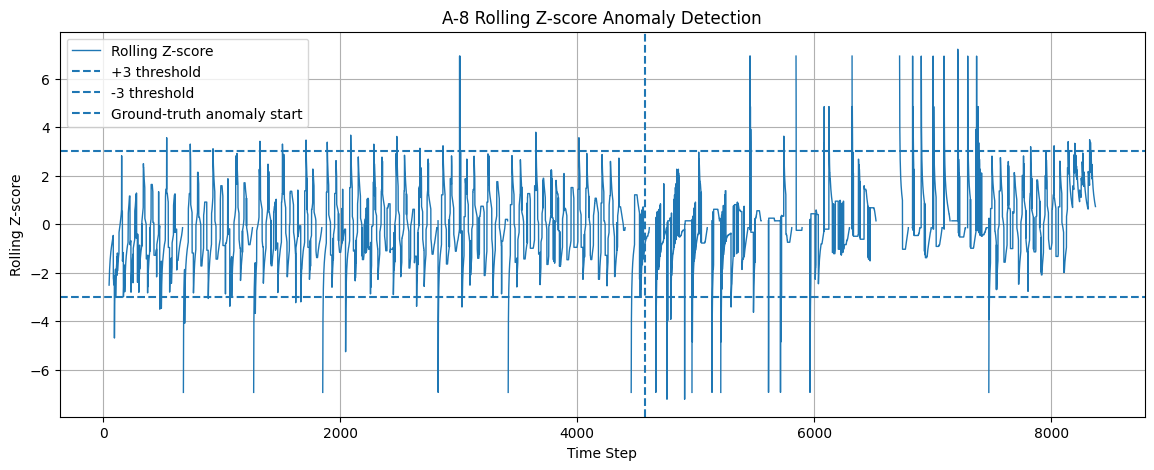

In [10]:
# Plot the rolling Z-score and anomaly threshold.
plt.figure(figsize=(14, 5))

plt.plot(
    rolling_z_A8,
    label="Rolling Z-score",
    linewidth=1
)

plt.axhline(
    threshold,
    linestyle="--",
    label="+3 threshold"
)

plt.axhline(
    -threshold,
    linestyle="--",
    label="-3 threshold"
)

plt.axvline(
    anomaly_start,
    linestyle="--",
    label="Ground-truth anomaly start"
)

plt.title("A-8 Rolling Z-score Anomaly Detection")
plt.xlabel("Time Step")
plt.ylabel("Rolling Z-score")
plt.legend()
plt.grid(True)

plt.show()

Rolling Z-score with a ±3 threshold detected some true anomalies (TP = 103), unlike the Global Z-score, which detected none. However, it also produced false positives because the local standard deviation became very small during flat or quantized telemetry segments. As a result, the method achieved low recall (2.71%) and low F1-score (0.052). This indicates that a naive rolling statistical threshold is insufficient for this channel and motivates more robust anomaly-detection methods.

##github commit

In [11]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Refresh index: 100% (19/19), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/13_evaluate_global_zscore.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/14_rolling_zscore.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
